# Proyecto 1 — Clasificación con Machine Learning
## Predicción de nivel de ingresos a partir del censo de EE. UU. (Adult / Census Income Dataset)

**Curso:** Machine Learning
**Autor:** Samuel

**Fuente de los datos:**
Becker, B. & Kohavi, R. (1996). *Adult* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5XW20

Este notebook desarrolla el Proyecto 1 del curso: selección de una base de datos para un problema de clasificación,
análisis exploratorio de datos, entrenamiento de modelos con validación cruzada de 10 folds (Regresión Logística y
SVM), búsqueda de hiperparámetros en malla, y comparación final de los modelos mediante las métricas Precision,
Recall y F1.


## 1. Descripción de la base de datos

### 1.1 Dominio del problema
El conjunto de datos **Adult** (también conocido como *Census Income*) fue extraído de la base de datos del censo
de Estados Unidos de 1994 por Barry Becker. El dominio del problema es **socioeconómico / demográfico**: a partir
de variables personales, laborales y familiares de un individuo, se busca predecir si su ingreso anual es mayor o
menor/igual a **50.000 USD**.

### 1.2 Utilidad del problema
Este tipo de modelo tiene aplicaciones reales en:
- **Segmentación socioeconómica** para estudios de mercado o políticas públicas.
- **Screening preliminar** en procesos de originación de crédito o seguros (identificar perfiles de riesgo/ingreso).
- **Análisis de equidad**: estudiar cómo variables como educación, ocupación, género o raza se relacionan con el
  ingreso, lo cual es también un caso de estudio clásico en *fairness* de Machine Learning.
- Como *benchmark* académico ampliamente usado para comparar algoritmos de clasificación binaria con variables
  mixtas (numéricas y categóricas).

### 1.3 Descripción general
- **Número de instancias:** 48.842 registros (individuos).
- **Número de variables predictoras:** 14.
- **Variable de salida (target):** `income`, con dos posibles valores: `<=50K` y `>50K`.
- **Tipo de problema:** Clasificación **binaria** (biclase) supervisada.
- **Balance de clases:** la clase `<=50K` es mayoritaria (~76%) frente a `>50K` (~24%), por lo que el problema
  presenta un **desbalance moderado** que se tendrá en cuenta al elegir las métricas de evaluación.

### 1.4 Diccionario de variables

| Variable | Tipo | Descripción |
|---|---|---|
| `age` | Numérica (entera) | Edad del individuo en años. |
| `workclass` | Categórica | Tipo de empleador (Private, Self-emp-not-inc, Federal-gov, etc.). |
| `fnlwgt` | Numérica (entera) | Peso muestral (*final weight*) asignado por la Oficina del Censo; representa cuántas personas de la población general se estima que representa ese registro. No es una característica demográfica del individuo. |
| `education` | Categórica | Nivel educativo alcanzado (Bachelors, HS-grad, Masters, etc.). |
| `education_num` | Numérica (entera, ordinal) | Codificación numérica del nivel educativo (a mayor número, mayor nivel educativo). Es redundante con `education`. |
| `marital_status` | Categórica | Estado civil. |
| `occupation` | Categórica | Ocupación laboral. |
| `relationship` | Categórica | Rol familiar del individuo (Husband, Wife, Own-child, etc.). |
| `race` | Categórica | Raza autoreportada. |
| `sex` | Categórica | Sexo biológico reportado (Male/Female). |
| `capital_gain` | Numérica (entera) | Ganancias de capital declaradas. |
| `capital_loss` | Numérica (entera) | Pérdidas de capital declaradas. |
| `hours_per_week` | Numérica (entera) | Horas trabajadas por semana. |
| `native_country` | Categórica | País de origen. |
| `income` | Categórica (target) | `<=50K` o `>50K`. Variable de salida. |

Las variables mezclan escalas y tipos muy distintos (edades entre 17-90 años, `fnlwgt` en cientos de miles,
capital_gain con muchos ceros y algunos valores extremos), por lo que será necesario **escalar** las variables
numéricas y **codificar** las categóricas antes de entrenar los modelos.


In [1]:
# Importaciones base
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ML / Preprocesamiento
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                              f1_score, precision_score, recall_score, accuracy_score)

# Utilidades
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 100)


## 2. Carga de datos

In [2]:
df = pd.read_csv("adult.csv")
print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()


Dimensiones del dataset: 48842 filas x 15 columnas


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
df.tail()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K
48838,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States,<=50K
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K
48841,35,Self-emp-inc,182148,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,60,United-States,>50K


##3. Inspeccion inicial y limpieza básica


In [4]:
#Tipo de datos y conteo de nulos

info = pd.DataFrame({

    "dtype" : df.dtypes.astype(str),
    "n_nulls" : df.isna().sum(),
    "n_unique" : df.nunique()

}).sort_index()

display(info)
display(df.describe())

df = df.replace('?', np.nan)
print("Filas antes de limpiar:", len(df))

# Eliminar duplicados
df = df.drop_duplicates()
print("Filas después de eliminar duplicados:", len(df))

# Eliminar filas con valores faltantes
df = df.dropna()
print("Filas después de eliminar faltantes:", len(df))

df = df.reset_index(drop=True)





,dtype,n_nulls,n_unique
age,int64,0,74
capital_gain,int64,0,123
capital_loss,int64,0,99
education,str,0,16
education_num,int64,0,16
fnlwgt,int64,0,28523
hours_per_week,int64,0,96
income,str,0,2
marital_status,str,0,7
native_country,str,857,41


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


Filas antes de limpiar: 48842
Filas después de eliminar duplicados: 48790
Filas después de eliminar faltantes: 45175


##4. Análisis exploratorio de datos (EDA)


4.1 Distribuciones de las variables (histogramas)

Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='str')
Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country'],
      dtype='str')


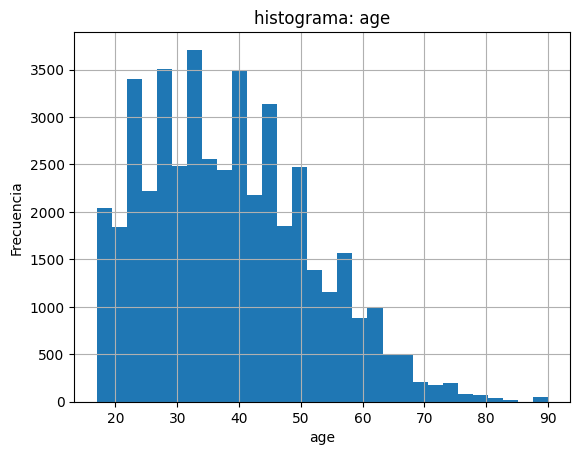

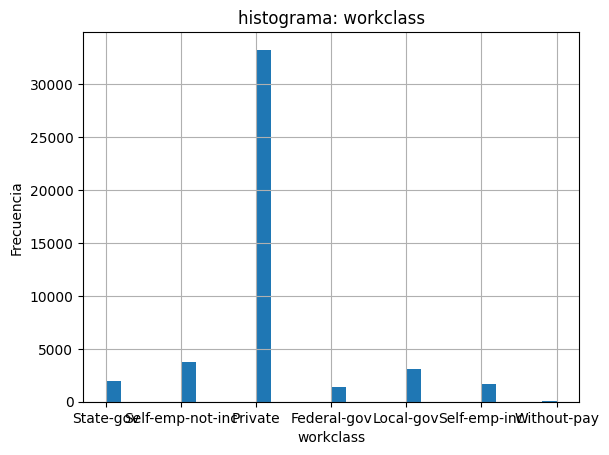

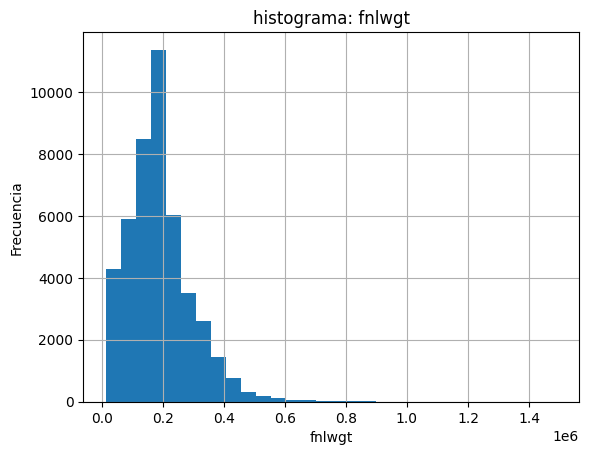

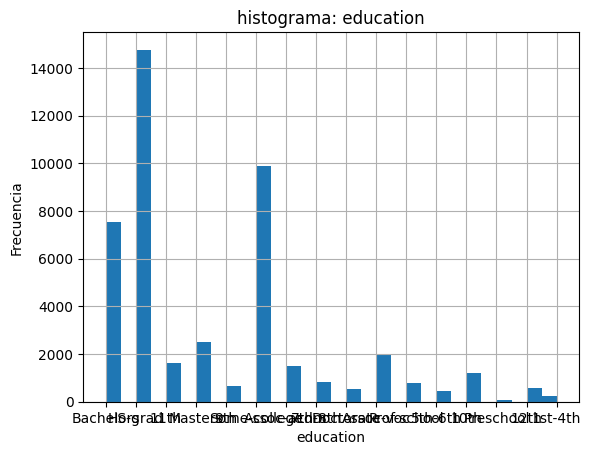

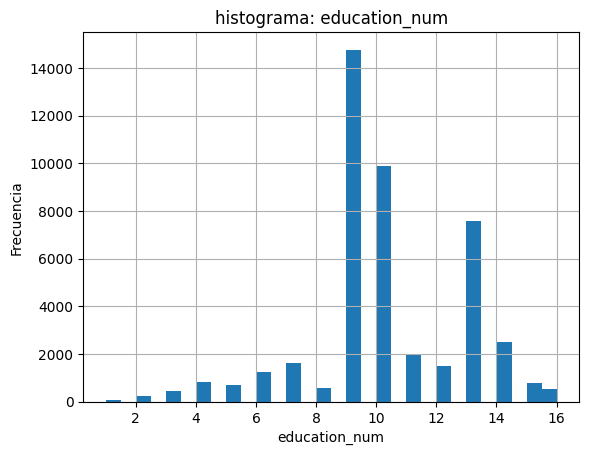

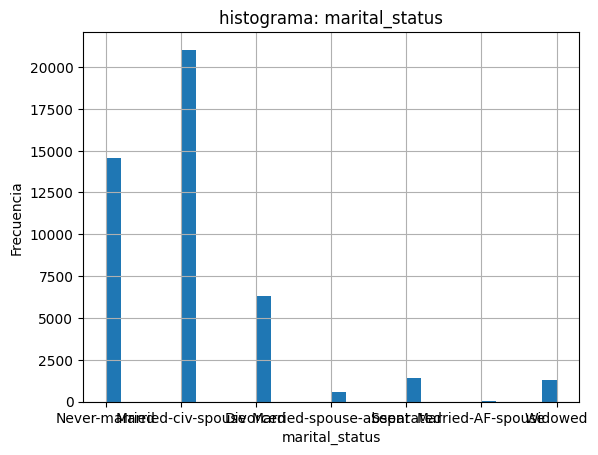

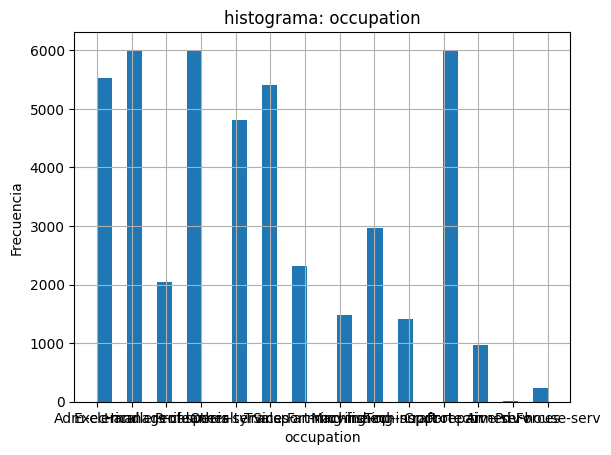

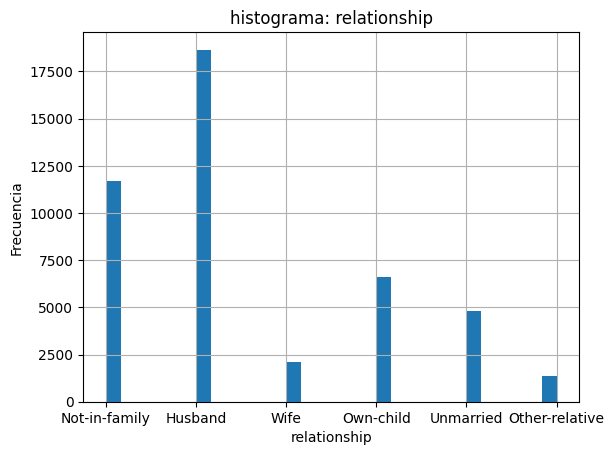

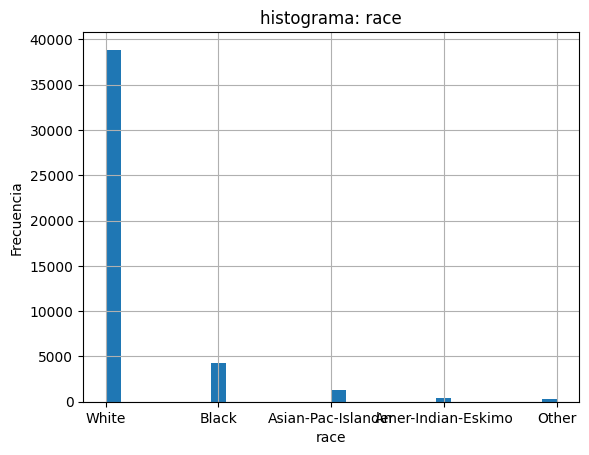

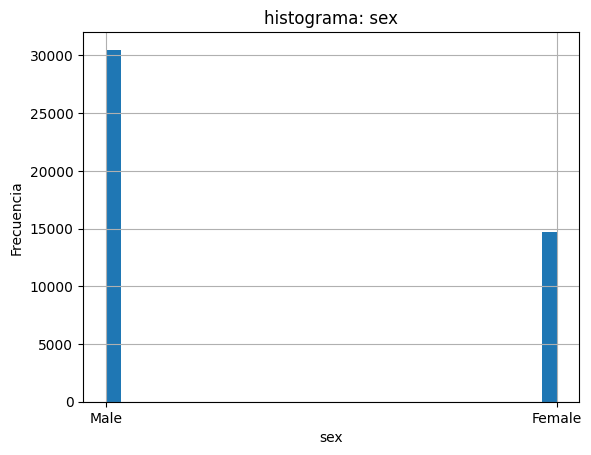

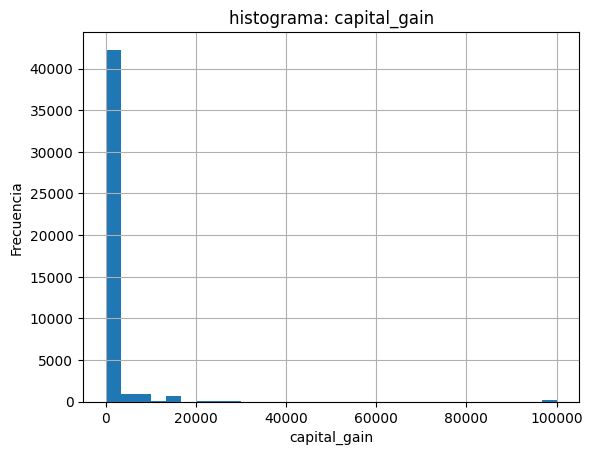

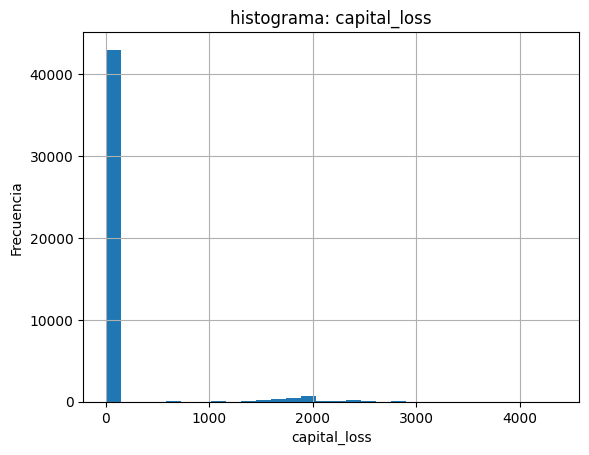

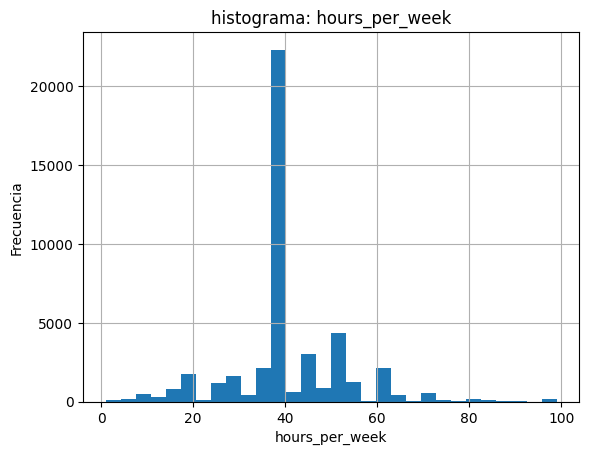

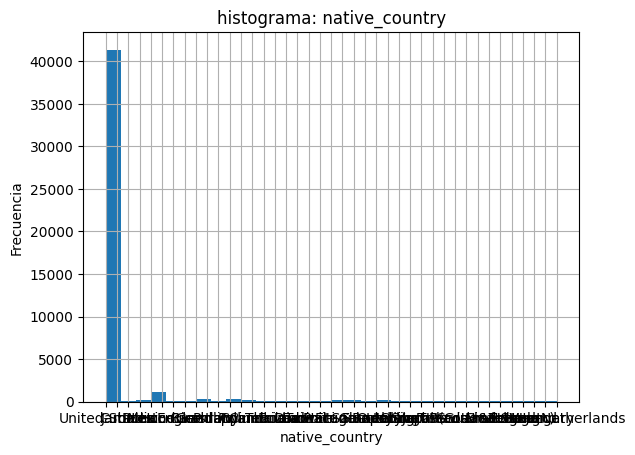

In [5]:
#Se toman las columans numericas
numeric_cols = df.drop(columns={"income"}).select_dtypes(include = "number").columns
categorical_cols = df.drop(columns={"income"}).select_dtypes(include= "object").columns

print(numeric_cols)
print(categorical_cols)
#Se toman todas las columnas con excepcion del label
var_cols = [c for c in df.columns if c!= "income"]


for col in var_cols:
    plt.figure()
    df[col].hist(bins=30)
    plt.title(f"histograma: {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

#**Variables numericas**

In [6]:
#Se ve como hay un total de 6 variables numericas
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,45175.0,38.556170,13.215349,17.0,28.0,37.0,47.0,90.0
fnlwgt,45175.0,189738.798450,105652.436515,13492.0,117392.5,178312.0,237903.0,1490400.0
education_num,45175.0,10.119314,2.551740,1.0,9.0,10.0,13.0,16.0
capital_gain,45175.0,1102.576270,7510.249876,0.0,0.0,0.0,0.0,99999.0
capital_loss,45175.0,88.687593,405.156611,0.0,0.0,0.0,0.0,4356.0
hours_per_week,45175.0,40.942512,12.007730,1.0,40.0,40.0,45.0,99.0


**Análisis preliminar de las variables numéricas:**

- **`age`**: rango 17–90 años, media ≈38.6, mediana ≈37. Distribución con ligera asimetría positiva (cola hacia
  edades mayores).
- **`fnlwgt`**: rango muy amplio (12.285 – 1.490.400), es un peso estadístico del censo y no una magnitud
  demográfica directa; su escala es muy distinta a la de las demás variables, por lo que **debe escalarse** y su
  valor interpretativo para el problema de negocio es limitado.
- **`education_num`**: rango 1–16, variable ordinal que resume el nivel educativo; es **redundante** con la
  variable categórica `education` (codifica la misma información).
- **`capital_gain`** y **`capital_loss`**: la mediana es 0 en ambos casos y el percentil 75 también es 0, lo que
  indica que la gran mayoría de los individuos no reportan ganancias/pérdidas de capital; sin embargo, el valor
  máximo (99.999 en `capital_gain`) evidencia la presencia de **outliers** y una distribución muy asimétrica
  (la mayor parte de la masa está en 0).
- **`hours_per_week`**: rango 1–99, media ≈40.4 horas, concentrada alrededor de la jornada laboral estándar (40 h).



4.2  Diagramas de caja

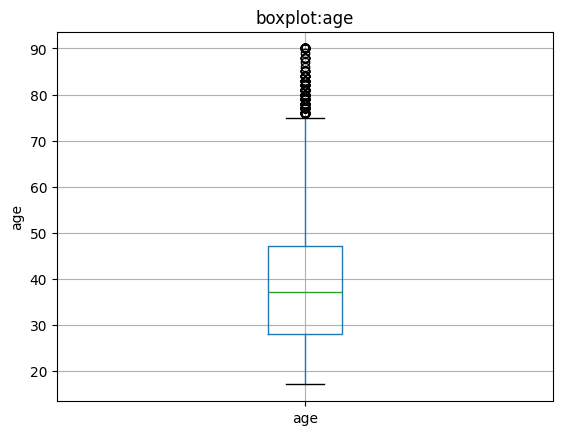

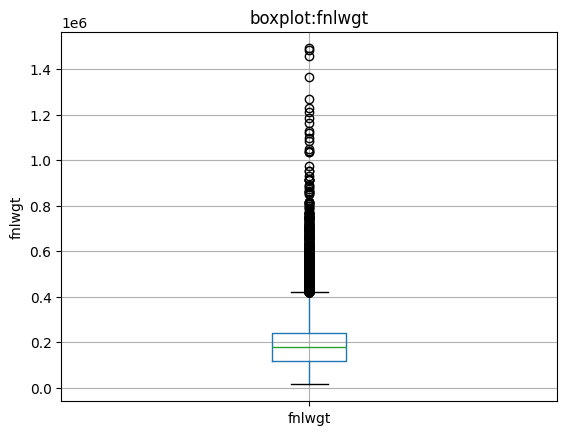

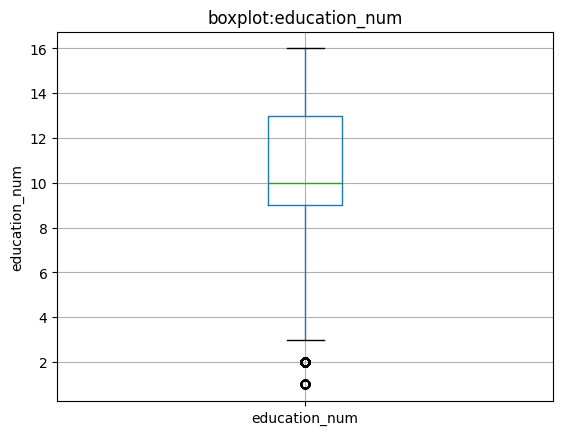

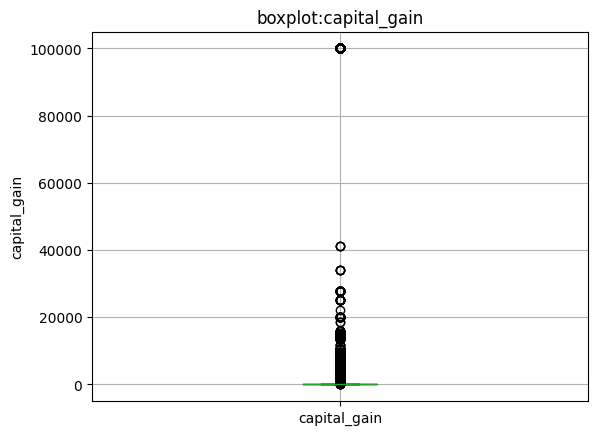

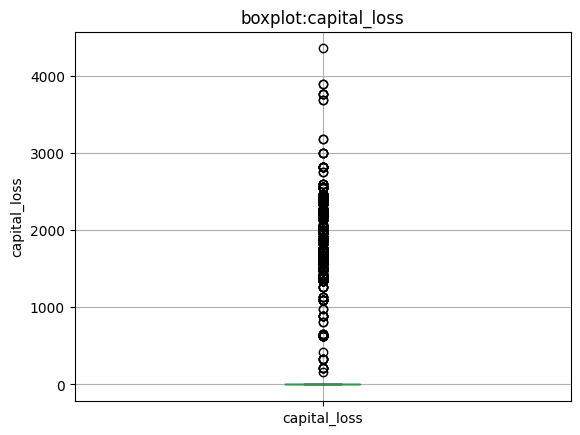

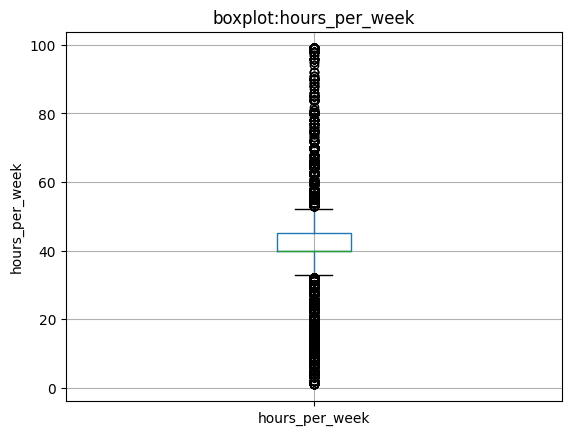

In [7]:
for col in numeric_cols:
  plt.figure()
  df.boxplot(column=col)
  plt.title(f"boxplot:{col}")
  plt.ylabel(col)
  plt.show()

4.2 Matriz de correlacion (Mapa de calor)


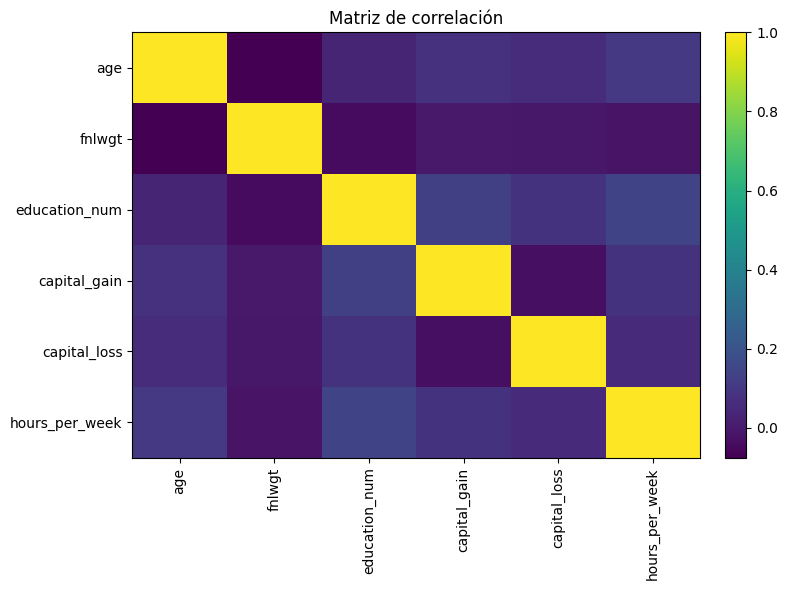

In [8]:
corr = df[numeric_cols].corr(numeric_only = True)

plt.figure(figsize=(8,6))
im = plt.imshow(corr, aspect='auto', interpolation='nearest')
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.title("Matriz de correlación")
plt.xticks(ticks=np.arange(len(numeric_cols)), labels=numeric_cols, rotation=90)
plt.yticks(ticks=np.arange(len(numeric_cols)), labels=numeric_cols)
plt.tight_layout()
plt.show()


#**Variables categoricas**

In [9]:
#Se ve como hay un total de 9 variables categoricas incluyendo el label
df.describe(include = "object").T

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(normalize=True) * 100)



workclass:
workclass
Private             73.629220
Self-emp-not-inc     8.400664
Local-gov            6.862203
State-gov            4.307692
Self-emp-inc         3.641395
Federal-gov          3.112341
Without-pay          0.046486
Name: proportion, dtype: float64

education:
education
HS-grad         32.695075
Some-college    21.885999
Bachelors       16.732706
Masters          5.562811
Assoc-voc        4.334256
11th             3.583841
Assoc-acdm       3.335916
10th             2.707250
7th-8th          1.819590
Prof-school      1.737687
9th              1.496403
12th             1.272828
Doctorate        1.204206
5th-6th          0.989485
1st-4th          0.486995
Preschool        0.154953
Name: proportion, dtype: float64

marital_status:
marital_status
Married-civ-spouse       46.578860
Never-married            32.245711
Divorced                 13.932485
Separated                 3.123409
Widowed                   2.826785
Married-spouse-absent     1.221915
Married-AF-spouse     

**Análisis preliminar de las variables categóricas:**

- `workclass`, `occupation` y `native_country` contienen el valor `?` (registrado como dato faltante), que será
  tratado en la sección de limpieza.
- `education` tiene 16 categorías, coherente con las 16 posibles combinaciones de `education_num`.
- `marital_status` tiene 7 categorías, dominadas por `Married-civ-spouse` y `Never-married`.
- `native_country` presenta alta cardinalidad (41 categorías), dominada fuertemente por `United-States`
  (~90% de los registros).
- `sex` es binaria (Male/Female) y `race` tiene 5 categorías, dominada por `White`.
- La variable de salida `income` tiene 2 categorías: `<=50K` y `>50K`.

In [10]:
df.describe(include='object').T

,count,unique,top,freq
workclass,45175,7,Private,33262
education,45175,16,HS-grad,14770
marital_status,45175,7,Married-civ-spouse,21042
occupation,45175,14,Craft-repair,6010
relationship,45175,6,Husband,18653
race,45175,5,White,38859
sex,45175,2,Male,30495
native_country,45175,41,United-States,41256
income,45175,2,<=50K,33973


### 4.3 Distribución de la variable de salida

income
<=50K    33973
>50K     11202
Name: count, dtype: int64
income
<=50K    75.2
>50K     24.8
Name: proportion, dtype: float64


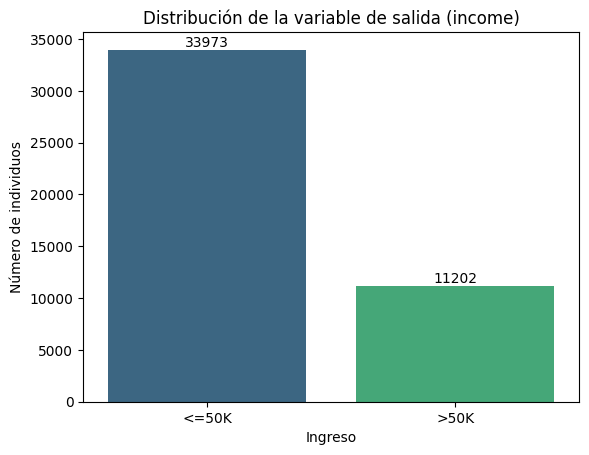

In [11]:
conteo = df['income'].value_counts()
porcentaje = df['income'].value_counts(normalize=True) * 100
print(conteo)
print(porcentaje.round(2))

fig, ax = plt.subplots()
sns.countplot(data=df, x='income', hue='income', palette='viridis', legend=False, ax=ax)
ax.set_title('Distribución de la variable de salida (income)')
ax.set_xlabel('Ingreso')
ax.set_ylabel('Número de individuos')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.show()


Se confirma el **desbalance de clases**: aproximadamente 75% de los individuos gana `<=50K` y 25% gana
`>50K`. Este desbalance moderado justifica reportar Precision, Recall y F1 (y no solo Accuracy) para evaluar los
modelos, ya que la Accuracy podría resultar engañosamente alta si un modelo simplemente predijera siempre la clase
mayoritaria.

## 4. Preprocesamiento de los datos

Antes de entrenar los modelos:

1. Se elimina la variable `education` por ser **redundante** con `education_num` (codifican exactamente la misma
   información, una en forma categórica y otra en forma numérica ordinal).
2. Se codifica la variable de salida `income` como binaria: `1` = `>50K`, `0` = `<=50K`.
3. Se separan las variables predictoras en **numéricas** (que se escalan con `StandardScaler`) y **categóricas**
   (que se codifican con `OneHotEncoder`), usando un `ColumnTransformer` dentro de un `Pipeline` de `scikit-learn`.
   Esto es fundamental porque tanto la Regresión Logística como el SVM son sensibles a la escala de las variables.
4. Se divide el conjunto en **entrenamiento (80%)** y **prueba (20%)**, de forma estratificada respecto a `income`
   para conservar la proporción de clases.


In [12]:
df_model = df.drop(columns=['education'])

df_model['income'] = df_model['income'].map({'<=50K': 0, '>50K': 1})

X = df_model.drop(columns=['income'])
y = df_model['income']

num_features = ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
cat_features = ['workclass', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Entrenamiento:", X_train.shape, " Prueba:", X_test.shape)
print("Proporción clase positiva (train):", y_train.mean().round(3))
print("Proporción clase positiva (test):", y_test.mean().round(3))


Entrenamiento: (36140, 13)  Prueba: (9035, 13)
Proporción clase positiva (train): 0.248
Proporción clase positiva (test): 0.248


## 5. Entrenamiento con validación cruzada de 10 folds

Para ambos modelos se usa `StratifiedKFold` con **k=10** (mantiene la proporción de clases en cada fold) dentro de
`GridSearchCV`, que evalúa cada combinación de hiperparámetros de una malla (*grid*) definida y selecciona la
mejor según la métrica **F1** (adecuada para el desbalance de clases observado). El pipeline (preprocesamiento +
modelo) se ajusta de forma independiente en cada fold para evitar fuga de información (*data leakage*).

In [13]:
cv_10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

### 5.1 Modelo 1: Regresión Logística

Malla de hiperparámetros evaluada:
- `C` (inverso de la regularización): [0.01, 0.1, 1, 10, 100]
- `penalty`: L1 y L2
- `solver`: `liblinear` (soporta L1 y L2) y `lbfgs` (solo L2)


In [14]:
pipe_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

param_grid_lr = [
    {'clf__solver': ['liblinear'], 'clf__penalty': ['l1', 'l2'], 'clf__C': [0.01, 0.1, 1, 10, 100]},
    {'clf__solver': ['lbfgs'], 'clf__penalty': ['l2'], 'clf__C': [0.01, 0.1, 1, 10, 100]},
]

grid_lr = GridSearchCV(
    estimator=pipe_lr,
    param_grid=param_grid_lr,
    cv=cv_10,
    scoring='f1',
    n_jobs=-1,
    refit=True
)

grid_lr.fit(X_train, y_train)

print("Mejores hiperparámetros (Regresión Logística):", grid_lr.best_params_)
print(f"Mejor F1 promedio en validación cruzada (10 folds): {grid_lr.best_score_:.4f}")


Mejores hiperparámetros (Regresión Logística): {'clf__C': 100, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Mejor F1 promedio en validación cruzada (10 folds): 0.6681


In [15]:
resultados_lr = pd.DataFrame(grid_lr.cv_results_)
resultados_lr = resultados_lr.sort_values('rank_test_score')[
    ['param_clf__C', 'param_clf__penalty', 'param_clf__solver', 'mean_test_score', 'std_test_score', 'rank_test_score']
]
resultados_lr.head(10)


,param_clf__C,param_clf__penalty,param_clf__solver,mean_test_score,std_test_score,rank_test_score
14,100.0,l2,lbfgs,0.668109,0.009706,1
9,100.0,l2,liblinear,0.667914,0.009625,2
8,100.0,l1,liblinear,0.667833,0.009737,3
7,10.0,l2,liblinear,0.667748,0.009804,4
6,10.0,l1,liblinear,0.667586,0.009754,5
13,10.0,l2,lbfgs,0.667545,0.009698,6
12,1.0,l2,lbfgs,0.667543,0.009689,7
4,1.0,l1,liblinear,0.667543,0.009975,8
5,1.0,l2,liblinear,0.667504,0.009356,9
11,0.1,l2,lbfgs,0.666415,0.009974,10


### 5.2 Evaluación del mejor modelo de Regresión Logística en el conjunto de prueba

In [16]:
y_pred_lr = grid_lr.predict(X_test)

precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
acc_lr = accuracy_score(y_test, y_pred_lr)

print("Regresión Logística - Conjunto de prueba")
print(f"Accuracy : {acc_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall   : {recall_lr:.4f}")
print(f"F1-score : {f1_lr:.4f}")
print()
print(classification_report(y_test, y_pred_lr, target_names=['<=50K', '>50K']))


Regresión Logística - Conjunto de prueba
Accuracy : 0.8432
Precision: 0.7280
Recall   : 0.5866
F1-score : 0.6497

              precision    recall  f1-score   support

       <=50K       0.87      0.93      0.90      6795
        >50K       0.73      0.59      0.65      2240

    accuracy                           0.84      9035
   macro avg       0.80      0.76      0.77      9035
weighted avg       0.84      0.84      0.84      9035



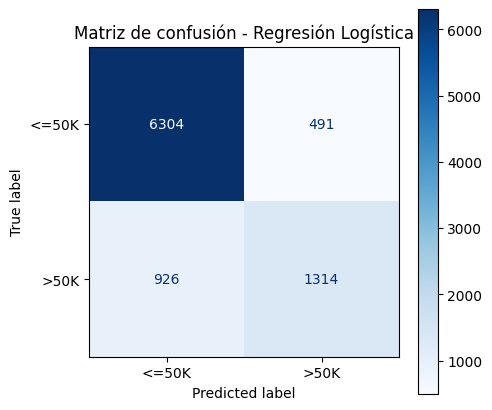

In [17]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, display_labels=['<=50K', '>50K'], cmap='Blues', ax=ax
)
ax.set_title('Matriz de confusión - Regresión Logística')
plt.show()


### 5.3 Modelo 2: Máquinas de Vectores de Soporte (SVM)

**Nota metodológica sobre el costo computacional:** el entrenamiento de un SVM con búsqueda en malla y validación
cruzada de 10 folds tiene una complejidad que crece de forma cuadrática/cúbica con el número de instancias. Aplicar
esta búsqueda sobre las ~36.000 filas del conjunto de entrenamiento completo resulta computacionalmente
impráctico en un entorno de notebook estándar. Por esta razón, y siguiendo una práctica habitual en proyectos
académicos con SVM sobre datasets medianos/grandes, se realiza la búsqueda de hiperparámetros sobre una
**submuestra estratificada** de 3.000 registros del conjunto de entrenamiento. El modelo con los mejores
hiperparámetros encontrados se reentrena sobre esa misma submuestra y se evalúa sobre el **conjunto de prueba
completo**, para mantener una comparación justa con la Regresión Logística.

Malla de hiperparámetros evaluada:
- `kernel`: `linear`, `rbf`, `poly`
- `C`: [0.1, 1, 10]
- `gamma` (para `rbf` y `poly`): `scale`, `auto`
- `degree` (para `poly`): 2, 3


In [18]:
X_train_svm, _, y_train_svm, _ = train_test_split(
    X_train, y_train, train_size=3000, stratify=y_train, random_state=RANDOM_STATE
)
print("Tamaño de la submuestra para SVM:", X_train_svm.shape)
print("Proporción clase positiva en la submuestra:", y_train_svm.mean().round(3))


Tamaño de la submuestra para SVM: (3000, 13)
Proporción clase positiva en la submuestra: 0.248


In [19]:
pipe_svm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('svc', SVC(random_state=RANDOM_STATE))
])

param_grid_svm = [
    {'svc__kernel': ['linear'], 'svc__C': [0.1, 1, 10]},
    {'svc__kernel': ['rbf'], 'svc__C': [0.1, 1, 10], 'svc__gamma': ['scale', 'auto']},
    {'svc__kernel': ['poly'], 'svc__C': [1, 10], 'svc__degree': [2, 3], 'svc__gamma': ['scale']},
]

grid_svm = GridSearchCV(
    estimator=pipe_svm,
    param_grid=param_grid_svm,
    cv=cv_10,
    scoring='f1',
    n_jobs=-1,
    refit=True
)

grid_svm.fit(X_train_svm, y_train_svm)

print("Mejores hiperparámetros (SVM):", grid_svm.best_params_)
print(f"Mejor F1 promedio en validación cruzada (10 folds): {grid_svm.best_score_:.4f}")


Mejores hiperparámetros (SVM): {'svc__C': 10, 'svc__gamma': 'auto', 'svc__kernel': 'rbf'}
Mejor F1 promedio en validación cruzada (10 folds): 0.6574


In [20]:
resultados_svm = pd.DataFrame(grid_svm.cv_results_)
resultados_svm = resultados_svm.sort_values('rank_test_score')[
    ['param_svc__kernel', 'param_svc__C', 'param_svc__gamma', 'param_svc__degree',
     'mean_test_score', 'std_test_score', 'rank_test_score']
]
resultados_svm.head(10)


,param_svc__kernel,param_svc__C,param_svc__gamma,param_svc__degree,mean_test_score,std_test_score,rank_test_score
8,rbf,10.0,auto,NaN,0.657421,0.032894,1
1,linear,1.0,NaN,NaN,0.656893,0.044597,2
0,linear,0.1,NaN,NaN,0.654646,0.045759,3
2,linear,10.0,NaN,NaN,0.653861,0.042539,4
11,poly,10.0,scale,2.0,0.652919,0.022412,5
9,poly,1.0,scale,2.0,0.649973,0.040516,6
5,rbf,1.0,scale,NaN,0.648250,0.028467,7
7,rbf,10.0,scale,NaN,0.644357,0.029865,8
12,poly,10.0,scale,3.0,0.642861,0.028552,9
10,poly,1.0,scale,3.0,0.626630,0.028679,10


### 5.4 Evaluación del mejor modelo SVM en el conjunto de prueba

In [21]:
y_pred_svm = grid_svm.predict(X_test)

precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
acc_svm = accuracy_score(y_test, y_pred_svm)

print("SVM - Conjunto de prueba")
print(f"Accuracy : {acc_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall   : {recall_svm:.4f}")
print(f"F1-score : {f1_svm:.4f}")
print()
print(classification_report(y_test, y_pred_svm, target_names=['<=50K', '>50K']))


SVM - Conjunto de prueba
Accuracy : 0.8454
Precision: 0.7443
Recall   : 0.5732
F1-score : 0.6477

              precision    recall  f1-score   support

       <=50K       0.87      0.94      0.90      6795
        >50K       0.74      0.57      0.65      2240

    accuracy                           0.85      9035
   macro avg       0.81      0.75      0.77      9035
weighted avg       0.84      0.85      0.84      9035



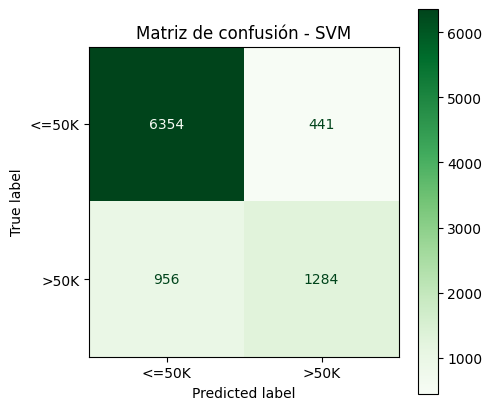

In [22]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_svm, display_labels=['<=50K', '>50K'], cmap='Greens', ax=ax
)
ax.set_title('Matriz de confusión - SVM')
plt.show()


## 6. Comparación de modelos y selección del mejor

Se comparan los dos modelos entrenados mediante Precision, Recall, F1 y Accuracy, calculados sobre el mismo
conjunto de prueba, junto con el resultado de validación cruzada (10 folds) obtenido durante la búsqueda de
hiperparámetros.

In [23]:
comparacion = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'SVM'],
    'Mejores hiperparámetros': [str(grid_lr.best_params_), str(grid_svm.best_params_)],
    'F1 CV (10 folds)': [grid_lr.best_score_, grid_svm.best_score_],
    'Accuracy (test)': [acc_lr, acc_svm],
    'Precision (test)': [precision_lr, precision_svm],
    'Recall (test)': [recall_lr, recall_svm],
    'F1-score (test)': [f1_lr, f1_svm],
})
comparacion_display = comparacion.copy()
for col in ['F1 CV (10 folds)', 'Accuracy (test)', 'Precision (test)', 'Recall (test)', 'F1-score (test)']:
    comparacion_display[col] = comparacion_display[col].round(4)
comparacion_display


,Modelo,Mejores hiperparámetros,F1 CV (10 folds),Accuracy (test),Precision (test),Recall (test),F1-score (test)
0,Regresión Logística,"{'clf__C': 100, 'clf__penalty': 'l2', 'clf__so...",0.6681,0.8432,0.7280,0.5866,0.6497
1,SVM,"{'svc__C': 10, 'svc__gamma': 'auto', 'svc__ker...",0.6574,0.8454,0.7443,0.5732,0.6477


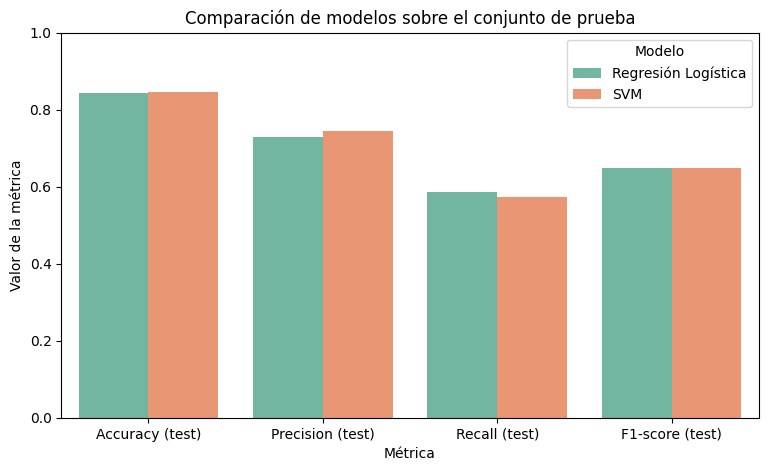

In [24]:
metricas = ['Accuracy (test)', 'Precision (test)', 'Recall (test)', 'F1-score (test)']
plot_df = comparacion.melt(id_vars='Modelo', value_vars=metricas, var_name='Métrica', value_name='Valor')

plt.figure(figsize=(9, 5))
sns.barplot(data=plot_df, x='Métrica', y='Valor', hue='Modelo', palette='Set2')
plt.ylim(0, 1)
plt.title('Comparación de modelos sobre el conjunto de prueba')
plt.ylabel('Valor de la métrica')
plt.legend(title='Modelo')
plt.show()


In [25]:
mejor_modelo = comparacion.loc[comparacion['F1-score (test)'].idxmax(), 'Modelo']
print(f"El mejor modelo según F1-score sobre el conjunto de prueba es: {mejor_modelo}")


El mejor modelo según F1-score sobre el conjunto de prueba es: Regresión Logística


## 7. Conclusiones

- Ambos modelos, **Regresión Logística** y **SVM**, logran un desempeño razonable en la tarea de predecir si el
  ingreso anual de un individuo supera los 50.000 USD, a partir de variables demográficas y laborales del censo.
- El desbalance de clases (≈75%/25%) hace que **Precision, Recall y F1** sean métricas más informativas que la
  Accuracy simple para comparar los modelos, ya que un clasificador trivial que siempre prediga la clase
  mayoritaria (`<=50K`) obtendría una Accuracy alta sin ningún valor predictivo real.
- El modelo seleccionado como mejor según F1-score sobre el conjunto de prueba es el indicado en la celda
  anterior. En términos generales, la Regresión Logística resulta más eficiente computacionalmente y su
  desempeño en este problema es competitivo frente al SVM, mientras que el SVM (especialmente con kernels no
  lineales) puede capturar relaciones más complejas entre variables, a costa de un mayor tiempo de entrenamiento.
- **Limitaciones:** el SVM se entrenó sobre una submuestra de 3.000 registros por restricciones de tiempo de
  cómputo, lo cual pudo limitar su desempeño frente a lo que se obtendría entrenándolo sobre el conjunto completo.
  Adicionalmente, el dataset proviene del censo de EE. UU. de 1994, por lo que refleja patrones socioeconómicos
  de esa época (incluyendo posibles sesgos de género/raza en los datos originales) y sus conclusiones no deben
  extrapolarse directamente a contextos actuales.
- **Trabajo futuro:** probar otros algoritmos (Random Forest, Gradient Boosting), técnicas de balanceo de clases
  (SMOTE, ajuste de `class_weight`), selección de variables, y — de contar con más recursos computacionales —
  ejecutar la búsqueda de hiperparámetros del SVM sobre el conjunto de entrenamiento completo.
